In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time


In [6]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data = []
labels = []

for i in range(1, 6):
    batch = unpickle(f"cifar-10-batches-py/data_batch_{i}")
    data.append(batch[b'data'])
    labels.extend(batch[b'labels'])

X_train = np.vstack(data).reshape(-1, 3, 32, 32)  # shape: (50000, 3, 32, 32)
y_train = np.array(labels)

test_batch = unpickle("cifar-10-batches-py/test_batch")
X_test = test_batch[b'data'].reshape(-1, 3, 32, 32)
y_test = np.array(test_batch[b'labels'])

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

df_labels = pd.DataFrame(y_train, columns=["label"])
print(df_labels.head())

Train: (50000, 3, 32, 32) (50000,)
Test : (10000, 3, 32, 32) (10000,)
   label
0      6
1      9
2      9
3      4
4      1


In [8]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data = []
labels = []
for i in range(1, 6):
    batch = unpickle(f"cifar-10-batches-py/data_batch_{i}")
    data.append(batch[b'data'])
    labels.extend(batch[b'labels'])

X_train = np.vstack(data)
y_train = np.array(labels)

test_batch = unpickle("cifar-10-batches-py/test_batch")
X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (50000, 3072) (50000,)
Test : (10000, 3072) (10000,)


In [4]:
# CIFAR-10 class names
class_names = [
    'airplane', 
    'automobile', 
    'bird',
    'cat', 
    'deer',
    'dog',
    'frog', 
    'horse',
    'ship',
    'truck']

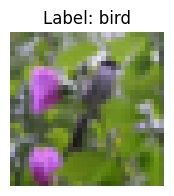

In [7]:
n = 300
y_label = y_train[n]

plt.figure(figsize=(2,2))
plt.imshow(np.transpose(X_train[n], (1, 2, 0)))
plt.title(f"Label: {class_names[y_label]}")
plt.axis('off')
plt.show()

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(0.99) 
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train.shape)
print("After PCA shape:", X_train_pca.shape)


Original shape: (50000, 3072)
After PCA shape: (50000, 662)


In [10]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start = time.time()
clf.fit(X_train_pca, y_train)
end = time.time()
print("Training time:", round(end - start, 2), "sec")

y_pred = clf.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", acc)

Training time: 61.76 sec
Random Forest Accuracy: 0.3884


In [11]:
from sklearn.linear_model import LogisticRegression
import time

log_reg = LogisticRegression(
    max_iter=200,
    solver='saga',
    multi_class='multinomial',
    n_jobs=-1
)

start = time.time()
log_reg.fit(X_train_pca, y_train)
end = time.time()

print("Training time:", round(end - start, 2), "sec")

# Predict
y_pred_log = log_reg.predict(X_test_pca)

# Accuracy
acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", acc_log)


c:\Users\Mezon\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training time: 278.36 sec
Logistic Regression Accuracy: 0.4019


In [12]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(0.95)),
    ("log_reg", LogisticRegression(
        max_iter=200,
        solver='saga',
        multi_class='multinomial',
        n_jobs=-1
    ))
])

start = time.time()
pipe.fit(X_train, y_train)
end = time.time()

print("Training time:", round(end - start, 2), "sec")

y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Logistic Regression (with PCA & Scaling) Accuracy:", acc)

c:\Users\Mezon\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training time: 96.83 sec
Logistic Regression (with PCA & Scaling) Accuracy: 0.4064


In [13]:
import joblib 
joblib.dump(pipe, 'models/cifar10_log_reg_pipeline.pkl')
joblib.dump(clf, 'models/cifar10_random_forest.pkl')

['models/cifar10_random_forest.pkl']

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_clf = SVC(kernel="linear", C=1.0)

# Train
svm_clf.fit(X_train_pca, y_train.ravel())

# Predict
y_pred = svm_clf.predict(X_test_pca)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("SVM Accuracy with PCA:", acc)
